# Build and Test Clustering 

Using subject (genre), category, page counts, published date

#### Imports and Data 

In [62]:
import pandas as pd
import numpy as np
from sklearn.preprocessing import MinMaxScaler
from sklearn.cluster import KMeans
from sklearn.decomposition import PCA
import matplotlib.pyplot as plt
from sklearn.feature_extraction.text import TfidfVectorizer, ENGLISH_STOP_WORDS


In [32]:
df = pd.read_csv("../data/books.csv")
df["published_date"] = pd.to_datetime(df["published_date"], errors="coerce")
print(df.shape)
df.head()

(810, 11)


,title,authors,publisher,subject,categories,maturityRating,page_count,average_rating,ratings_count,published_date,description
0,The Dream of the Celt,Mario Vargas Llosa,Macmillan + ORM,fiction,Fiction,NOT_MATURE,455,0.0,0,2012-06-05,"This ""vast and intriguing novel"" explores the ..."
1,The Natural,Bernard Malamud,Macmillan,fiction,Fiction,NOT_MATURE,250,0.0,0,1952-01-01,Story of a baseball player's record-shattering...
2,Journey to the Center of the Earth,Jules Verne,Bantam,fiction,Fiction,NOT_MATURE,242,3.5,3,2006-04-25,The intrepid Professor Lindenbrock embarks upo...
3,Mysteries,Knut Hamsun,Penguin,fiction,Fiction,NOT_MATURE,356,4.0,3,2001-01-01,The first complete English translation of the ...
4,Cat's Cradle,Kurt Vonnegut,Dial Press Trade Paperback,fiction,Fiction,NOT_MATURE,308,4.0,147,1998-09-08,“A free-wheeling vehicle . . . an unforgettabl...


#### Publishing Year extract 

In [33]:
#just get year 
df["publish_year"] = df["published_date"].dt.year

In [34]:
#check for missing dates 
df["publish_year"].isna().sum()

#if missing dates, fill with median year
median_year = df["publish_year"].median()
df["publish_year"] = df["publish_year"].fillna(median_year)

In [35]:
#year range 
print(f"publish year range: {df['publish_year'].min()} - {df['publish_year'].max() }")

publish year range: 1951 - 2026


#### normalize page counts and publish year 

In [36]:
scaler = MinMaxScaler()

#scale to be between 0 and 1 for clustering
# df["page_count_scaled"] = scaler.fit_transform(df[["page_count"]])
# df["publish_year_scaled"] = scaler.fit_transform(df[["publish_year"]])
df[["page_count_scaled", "publish_year_scaled"]] = scaler.fit_transform(df[["page_count", "publish_year"]])

#confirm 
print(df[["page_count_scaled", "publish_year_scaled"]].describe())


       page_count_scaled  publish_year_scaled
count         810.000000           810.000000
mean            0.141896             0.660165
std             0.078121             0.215998
min             0.000000             0.000000
25%             0.094881             0.533333
50%             0.129422             0.706667
75%             0.172493             0.840000
max             1.000000             1.000000


#### Encode genres and categories

In [37]:
#turn genre into indicator columns with one hot encoding
subject_dummies = pd.get_dummies(df["subject"], prefix="subject")
subject_dummies.head()

,subject_fantasy,subject_fiction,subject_historical fiction,subject_mystery,subject_nonfiction,subject_romance,subject_science,subject_science fiction,subject_self help,subject_thriller
0,False,True,False,False,False,False,False,False,False,False
1,False,True,False,False,False,False,False,False,False,False
2,False,True,False,False,False,False,False,False,False,False
3,False,True,False,False,False,False,False,False,False,False
4,False,True,False,False,False,False,False,False,False,False


In [38]:
#turn categories into indicator columns with one hot encoding

#first deal with instances of list of categories 
category_dummies = df["categories"].str.get_dummies(sep=",")
#add prefix to columns
category_dummies.columns = ["category_"+col for col in category_dummies.columns]
category_dummies.head()

,category_ 1921-1922,category_ Ancient,category_ Calif.),"category_ Charlie ""Bird"" (Fictitious character)",category_ English,category_ Mind & Spirit,category_ N.Y.),category_ Swedish,category_ Temperance (Fictitious character),category_ The,...,category_Romance fiction,category_Science,category_Self,category_Self-Help,category_Social Science,category_Technology & Engineering,category_Thriller - Fiction,category_Travel,category_Unknown,category_Young Adult Fiction
0,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
1,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
2,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
3,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
4,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0


In [39]:
#keep categories that appear in at least 5 books 
cat_columns = category_dummies.columns.tolist()
keep_cats = [col for col in cat_columns if category_dummies[col].sum() >= 5]

print("before category columns: ", len(cat_columns))
print("after category columns: ", len(keep_cats))

before category columns:  142
after category columns:  26


#### Add in TF-IDF to extract key words from description

In [69]:
df["description"] = df["description"].fillna("")

#create stop words list 
custom_stopwords = [
    # your original list
    'author', 'bestselling', 'book', 'books', 'novel', 'story', 'edition', 
    'fiction', 'history', 'just', 'make', 'man', 'new', 'readers', 'set', 
    'times', 'way', 'woman', 'written', 'years', 'york', 'best', 'literature', 
    'novels', 'published', 'research', 'science', 'series', 'stories', 'like', 
    'life', 'lives', 'home', 'world', 'time', 'people', 'long', 'old', 'young', 
    'great', 'known', 'journey', 'past', 'future', 'age', 'year',
    'including', 'important', 'information', 'use', 'work', 'works',
    'understanding', 'second', 'explores', 'finds', 'takes', 'offers', 'provides', 'read',
    'end', 'day', 'tale', 'ways', 'classic', 'original', 'comes', 'need', 'small', 'questions', 'public', 'personal',
    'authors', 'based', 'clear', 'different', 'experience', 'little', 'secrets', 'american'



]
all_stop_words = list(ENGLISH_STOP_WORDS.union(custom_stopwords))

#tf-idf, max features 50 
tfidf = TfidfVectorizer(
    max_features=50, #50 most meaningful words 
    stop_words = all_stop_words,
    min_df = 3 #word must appear in at least 3 books 
)

tfidf_matrix = tfidf.fit_transform(df['description']).toarray()
tfidf_df = pd.DataFrame(
    tfidf_matrix,
    columns = [f"tfidf_{term}" for term in tfidf.get_feature_names_out()]
)

print(f"tf-idf terms created: {tfidf_df.shape[1]}")
print("top words ", tfidf.get_feature_names_out().tolist())

tf-idf terms created: 50
top words  ['america', 'begins', 'body', 'century', 'change', 'child', 'children', 'city', 'contemporary', 'daughter', 'death', 'detective', 'development', 'english', 'family', 'fantasy', 'father', 'field', 'friend', 'girl', 'heart', 'help', 'high', 'historical', 'house', 'human', 'identity', 'knowledge', 'literary', 'love', 'men', 'modern', 'mother', 'murder', 'mystery', 'nature', 'political', 'power', 'scientific', 'secret', 'self', 'social', 'society', 'studies', 'study', 'technology', 'theory', 'town', 'war', 'women']


#### combine all features

In [70]:
features = pd.concat([
    df[["page_count_scaled", "publish_year_scaled"]],
    subject_dummies,
    category_dummies[keep_cats],
    tfidf_df
], axis = 1)



In [71]:
print("features shape: ", features.shape)
features.head()

features shape:  (810, 88)


,page_count_scaled,publish_year_scaled,subject_fantasy,subject_fiction,subject_historical fiction,subject_mystery,subject_nonfiction,subject_romance,subject_science,subject_science fiction,...,tfidf_self,tfidf_social,tfidf_society,tfidf_studies,tfidf_study,tfidf_technology,tfidf_theory,tfidf_town,tfidf_war,tfidf_women
0,0.184353,0.813333,False,True,False,False,False,False,False,False,...,0.000000,0.000000,0.0,0.0,0.0,0.0,0.0,0.000000,0.0,0.000000
1,0.099043,0.013333,False,True,False,False,False,False,False,False,...,0.000000,0.000000,0.0,0.0,0.0,0.0,0.0,0.000000,0.0,0.000000
2,0.095714,0.733333,False,True,False,False,False,False,False,False,...,0.000000,0.000000,0.0,0.0,0.0,0.0,0.0,0.000000,0.0,0.000000
3,0.143154,0.666667,False,True,False,False,False,False,False,False,...,0.000000,0.000000,0.0,0.0,0.0,0.0,0.0,0.324686,0.0,0.311824
4,0.123179,0.626667,False,True,False,False,False,False,False,False,...,0.484497,0.517448,0.0,0.0,0.0,0.0,0.0,0.000000,0.0,0.000000


In [72]:
#check null 
features.isna().sum().sum()

np.int64(0)

In [ ]:
# df[df["categories"] == "Unknown"]

,title,authors,publisher,subject,categories,maturityRating,page_count,average_rating,ratings_count,published_date,description,publish_year,page_count_scaled,publish_year_scaled,cluster_11,cluster_14,cluster_12,cluster_13,cluster
11,The House of the Seven Gables,Nathaniel Hawthorne,CreateSpace,fiction,Unknown,NOT_MATURE,250,0.0,0,2015-04-11,The House of the Seven Gables By Nathaniel Haw...,2015,0.099043,0.853333,4,4,4,4,10
13,The Scarlet Letter Annotated,Nathaniel Hawthorne,Unknown,fiction,Unknown,NOT_MATURE,316,0.0,0,2021-01-05,"Set in an early New England colony, the novel ...",2021,0.126509,0.933333,4,4,4,4,10
19,The Tragedy of King Lear,William Shakespeare,Unknown,fiction,Unknown,NOT_MATURE,124,0.0,0,2020-12-22,King Lear is a tragedy written by William Shak...,2020,0.046608,0.920000,4,4,4,4,10
22,Pride and Prejudice,Jane Austen,Createspace Independent Publishing Platform,fiction,Unknown,NOT_MATURE,330,0.0,0,2017-09-29,Elizabeth Bennet is Austen's most liberated an...,2017,0.132335,0.880000,4,4,4,4,10
25,Typee Illustrated,Herman Melville,Unknown,fiction,Unknown,NOT_MATURE,406,0.0,0,2019-11-26,Typee: A Peep at Polynesian Life is the first ...,2019,0.163962,0.906667,4,4,4,4,10
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
768,Artificial Intelligence For Dummies,John Mueller,Unknown,nonfiction,Unknown,NOT_MATURE,336,0.0,0,2018-01-01,"Step into the future with AI The term ""Artific...",2018,0.134831,0.893333,6,6,6,6,8
778,Ride the Devil's Herd,John Boessenecker,Hanover Square Press,nonfiction,Unknown,NOT_MATURE,512,0.0,0,2021-11-02,"""A ripsnortin' ramble across the bloodstained ...",2021,0.208073,0.933333,6,6,6,6,8
786,Underland,Robert Macfarlane,Hamish Hamilton,nonfiction,Unknown,NOT_MATURE,496,0.0,0,2019-05-02,The highly anticipated new book from the inter...,2019,0.201415,0.906667,6,6,6,6,8
800,Astrology,Dorling Kindersley Publishing Staff,Unknown,nonfiction,Unknown,NOT_MATURE,256,0.0,0,2018-09-01,Find out how to use your birth horoscope to en...,2018,0.101540,0.893333,6,6,6,6,8


### K Means

Find K value - elbow method 

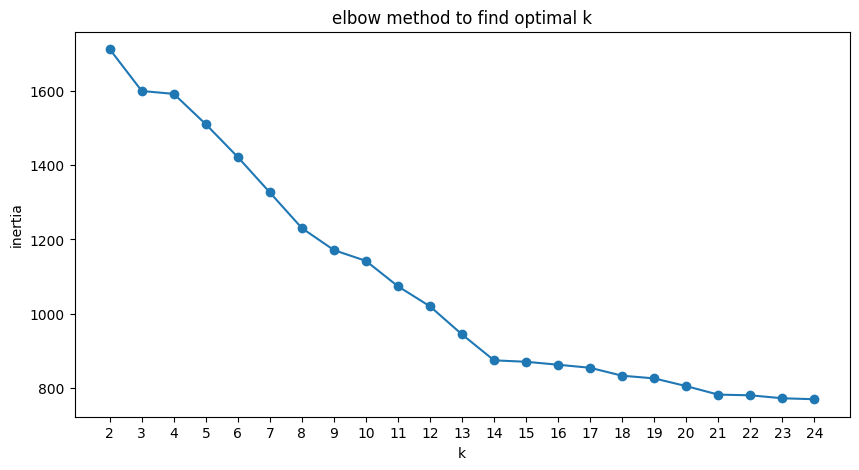

In [74]:
inertia = [] #track how tight clusters are
k_range = range(2, 25)

#test out ks 
for k in k_range:
    kmeans = KMeans(n_clusters=k, random_state=123)
    kmeans.fit(features)
    inertia.append(kmeans.inertia_)

#plot inertia to find elbow point
plt.figure(figsize=(10,5))
plt.plot(k_range, inertia, marker="o")
plt.title("elbow method to find optimal k")
plt.xlabel("k")
plt.ylabel("inertia")
plt.xticks(k_range)
plt.show()

somewhere in k = 14


In [ ]:
for k in [13, 14, 15]:
    kmeans = KMeans(n_clusters=k, random_state=123)
    kmeans.fit(features)
    df[f"cluster_{k}"] = kmeans.labels_
    print(f"\n{k} clusters")
    print(df[f"cluster_{k}"].value_counts().sort_index())


3 clusters
cluster_3
0      6
1    273
2    531
Name: count, dtype: int64

13 clusters
cluster_13
0       6
1     131
2      51
3      20
4      87
5      58
6      98
7      65
8      79
9      30
10     71
11     40
12     74
Name: count, dtype: int64

14 clusters
cluster_14
0      6
1     87
2     46
3     20
4     87
5     58
6     98
7     65
8     79
9     30
10    71
11    35
12    74
13    54
Name: count, dtype: int64

15 clusters
cluster_15
0      6
1     87
2     45
3     20
4     87
5     58
6     98
7     65
8     79
9     23
10    71
11    35
12    74
13    54
14     8
Name: count, dtype: int64


In [91]:
for cluster_id in [0, 3]:
    print(f"\n--- Cluster {cluster_id} ---")
    cluster_books = df[df["cluster_k13"] == cluster_id]
    print("Subjects:", cluster_books["subject"].value_counts().to_dict())
    print("Categories:", cluster_books["categories"].value_counts().head(5).to_dict())
    print("Titles:", cluster_books["title"].tolist())


--- Cluster 0 ---
Subjects: {'mystery': 87}
Categories: {'Fiction': 57, 'Detective and mystery stories': 6, 'Juvenile Fiction': 5, 'Mystery': 4, 'Drama': 2}
Titles: ['Missing Joseph', 'The Sleeping Doll', 'Tyrannosaur Canyon', 'The Runaway Jury', 'The Colorado Kid', 'Ten Big Ones', 'The Narrows', 'A Time to Kill', 'Windigo Island', 'The Invisible Man', 'Where are the Children?', 'Every Dead Thing', 'Dead Souls', 'For the Sake of Elena', 'Cards on the Table', 'Crime and Punishment', 'Frost Burned', 'Agatha Raisin and the Witch of Wyckhadden', 'The Dogs of Riga', 'The Seventh Function of Language', 'The Curious Incident of the Dog in the Night-time', 'Funeral in Blue', 'The Redeemer', 'Weep No More, My Lady', 'The Black Tower', 'The Clocks', 'Blood Brothers', 'The Tenth Justice', 'The Athenian Murders', 'Run River', 'High Five', 'The Curious Incident of the Dog in the Night-Time', 'Murder on the Orient Express', 'Still Waters', 'Busy Body', '"A" is for Alibi', 'Milk and Honey', 'Angels 

k = 11 best 


In [75]:
kmeans = KMeans(n_clusters=14, random_state=123, n_init=10)
kmeans.fit(features)
df["cluster"] = kmeans.labels_

print(df["cluster"].value_counts().sort_index())

cluster
0      51
1      87
2     100
3      29
4      76
5      59
6      79
7      24
8      46
9      86
10     71
11     30
12     38
13     34
Name: count, dtype: int64


### PCA 

In [53]:
pca = PCA(n_components=2, random_state=123)
pca_features = pca.fit_transform(features)

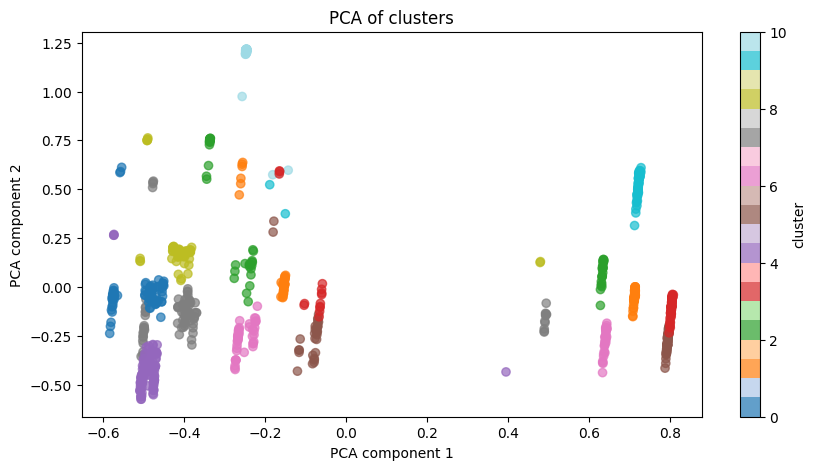

In [54]:
#plot PCA components colored by cluster
plt.figure(figsize=(10,5))
scatter = plt.scatter(
    pca_features[:,0], #x axis , first PCA component
    pca_features[:,1], #y axis, second PCA component
    c=df["cluster"],  # color by cluster assignment
    cmap="tab20", #20 distinct colors
    alpha=0.7
)
plt.colorbar(scatter, label="cluster")
plt.title("PCA of clusters")
plt.xlabel("PCA component 1")
plt.ylabel("PCA component 2")
plt.show()

look at each cluster 

In [55]:
for i in range(11):
    print(f"cluster {i}")
    cluster_books = df[df["cluster"] == i]
    print("subjects: ", cluster_books["subject"].value_counts().to_dict())
    print("categories: ", cluster_books["categories"].value_counts().to_dict())
    print("titles: ", cluster_books["title"].tolist()[:5]) 


cluster 0
subjects:  {'science': 88}
categories:  {'Science': 29, 'Nature': 9, 'Biography & Autobiography': 6, 'Medical': 6, 'Business & Economics': 4, 'Technology & Engineering': 4, 'Mathematics': 3, 'Computers': 3, 'History': 3, 'Unknown': 3, 'Social Science': 2, 'Language Arts & Disciplines': 2, 'Philosophy': 2, 'Gardening': 2, 'Health & Fitness': 2, 'Juvenile Nonfiction': 1, 'Art': 1, 'Biography': 1, 'Political Science': 1, 'Psychology': 1, 'Miniature books': 1, 'Civilization, Ancient': 1, 'Body, Mind & Spirit': 1}
titles:  ['Silent Spring', 'Longitude', 'The Beginning of the Age of Mammals', 'On the Revolutions of Heavenly Spheres', 'Conservation Biology for All']
cluster 1
subjects:  {'thriller': 79}
categories:  {'Fiction': 42, 'Unknown': 6, 'Adventure stories': 3, 'Thriller - Fiction': 2, 'Detective and mystery stories': 2, 'Brothers': 2, 'Art museum curators': 1, 'Parker, Charlie "Bird" (Fictitious character)': 1, 'Large print books': 1, 'JUVENILE FICTION': 1, 'Ex-convicts': 1

#### Save Model 

In [56]:
import joblib

#save model 
joblib.dump(kmeans, "../data/kmeans_model.pkl")

#save feature matrix column names 
joblib.dump(features.columns.tolist(), "../data/feature_columns.pkl")

#save scalar for page count and publish year 
joblib.dump(scaler, "../data/scaler.pkl")

#save clustered data
df.to_csv("../data/books.csv", index=False)


